# Xylella in an olive grove

**Part 1: the model, made fast and checked.**

A stochastic lattice model of *Xylella fastidiosa* spreading through an olive grove,
recreating Fierro, Liccardo & Porcelli (2019), *Scientific Reports* 9. Meadow
spittlebugs random-walk over a grid of shrub and olive-tree cells, pick the bacterium up
from infected trees and carry it to healthy ones. The bacterium blocks the tree's xylem;
symptoms - Olive Quick Decline Syndrome - appear about two years later.

This notebook:

1. runs the model and shows it moving - the seasonal swarm onto the trees is the most
   distinctive thing it does, and a static plot hides it
2. checks the fast rewrite is the same model as the original
3. runs it many times, because one run is one roll of the dice
4. tests the three assumptions doing the most work: the annual vector reset, infection
   on first contact, and simulating 0.1% of the real spittlebug population

Part 2 uses the transmission log recorded here to predict, from one measured run, the
felling radius that stops an outbreak - and compares it with the EU's rule.

In [1]:
import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

from olive_model import OliveGrove, run_ensemble, animate, _shade_seasons

plt.rcParams.update({'figure.figsize': (11, 5), 'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
os.makedirs('figures', exist_ok=True)
PROCESSES = max(1, (os.cpu_count() or 2) - 1)       # seeds run in parallel

## 1. The model

A 90 x 90 m grove at 1 m resolution. Olive trees are 3 x 3 cells on a 5 m grid - 256 of
them - and every other cell is shrub and grass, where spittlebugs spend most of the year.

| | |
|---|---|
| time step | 30 per day (the paper uses 48 half-hour steps) |
| movement | half the time, try one step in a random direction; whether it is taken depends on where from and to |
| shrub to shrub | 0.5 |
| shrub to tree | 1.0 in the tender-sprout season (days 90-185), 0 otherwise |
| tree to shrub | 0.005 in the tender season, 1.0 otherwise - hard sprouts push them off |
| within a tree | 0.3 |
| symptomatic trees | repel spittlebugs |
| tree infected by a carrier | probability 1 per contact |
| spittlebug infected by a tree | rises with how long the tree has been colonised, reaching 1 after about 90 days |
| symptoms | about 730 days after infection (normal, sd 100) |
| each spring (day 120) | a new generation of uninfected adults replaces the old one |
| spittlebugs | 810, which is 0.1% of the paper's million per hectare |

Infected trees with symptoms are what the original code calls "removed". Nothing is
felled in this model; "symptomatic" is the honest name, and it is used here.

three years in 5.7 s
trees ever infected: 62%, symptomatic by day 1095: 1%


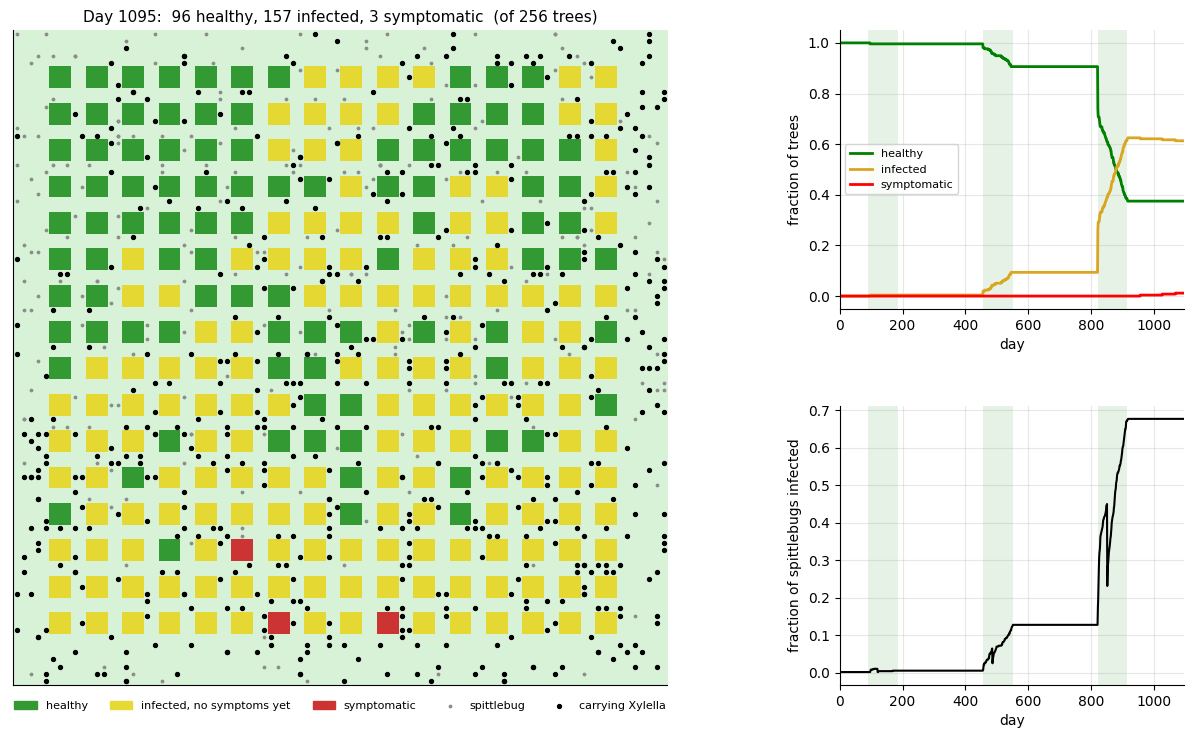

In [2]:
t = time.time()
grove = OliveGrove(sampling_rate=0.001, time_steps_per_day=30, seed=1, frame_every=4)
grove.run(365 * 3)
print(f"three years in {time.time() - t:.1f} s")
print(f"trees ever infected: {grove.ever_infected():.0%}, symptomatic by day {grove.day}: "
      f"{grove.series('R')[-1]:.0%}")

grove.visualize()
plt.savefig('figures/fig1_grove_day1095.png', dpi=110, bbox_inches='tight')
plt.show()

### Watching it move

Three years in about twenty seconds. Spittlebugs are dots - dark when carrying the
bacterium. The shrub layer turns a brighter green in the tender-sprout season, when the
spittlebugs swarm onto the trees; when the sprouts harden they are pushed back off.

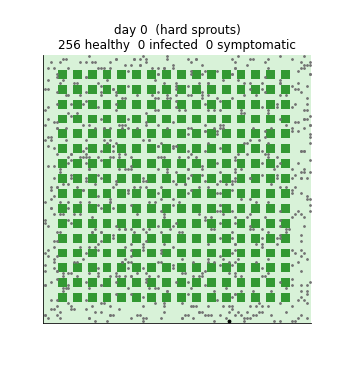

In [3]:
animate(grove, 'figures/fig0_animation.gif', fps=14)
Image(filename='figures/fig0_animation.gif')

The spread happens in pulses. Infection only moves from tree to tree during the ~95 days
a year when spittlebugs are on the trees; the rest of the year the shrub layer holds them.
So the epidemic advances in annual steps rather than smoothly - the staircase in the
infected curve. (Section 4 checks whether the spring reset of the spittlebug population
causes the steps too. It does not.)

## 2. Is the fast version the same model?

`olive_model.py` applies the original rules to every spittlebug at once instead of
looping over them, and replaces a scan over all 256 trees with a lookup table. It also
fixes four bugs (listed in its header). The two biggest:

- a spittlebug on the centre cell of a symptomatic tree had no shrub next to it, so the
  "repel" rule did nothing and it never moved again
- the check meant to tell "same tree" from "different tree" compared two cells one step
  apart, so it always said "same" (harmless at 5 m spacing - trees never touch - but dead
  code)

Most fixes only matter once trees turn symptomatic, after about two years - with one
exception. The original starts with tender-sprout movement on day 0, which is the hard
season. That looked cosmetic. It is not: on day 0 the infected spittlebug can climb onto a
tree and infect it, and that tree is then fully colonised by the time the real tender
season starts on day 90 - a whole season's head start.

So three versions are compared over the first 600 days:

- **original** - `OliveTree_SIR_model.py`
- **fast, legacy start** - `olive_model.py` with the original's day-0 behaviour switched
  back on. If the rewrite is faithful, this should match the original.
- **fast, fixed** - `olive_model.py` as it is used from here on

A stochastic model cannot be checked run for run, only by comparing the spread of outcomes
across many seeds. `compare_with_original.py` does that; it takes about an hour, because
the original is slow.

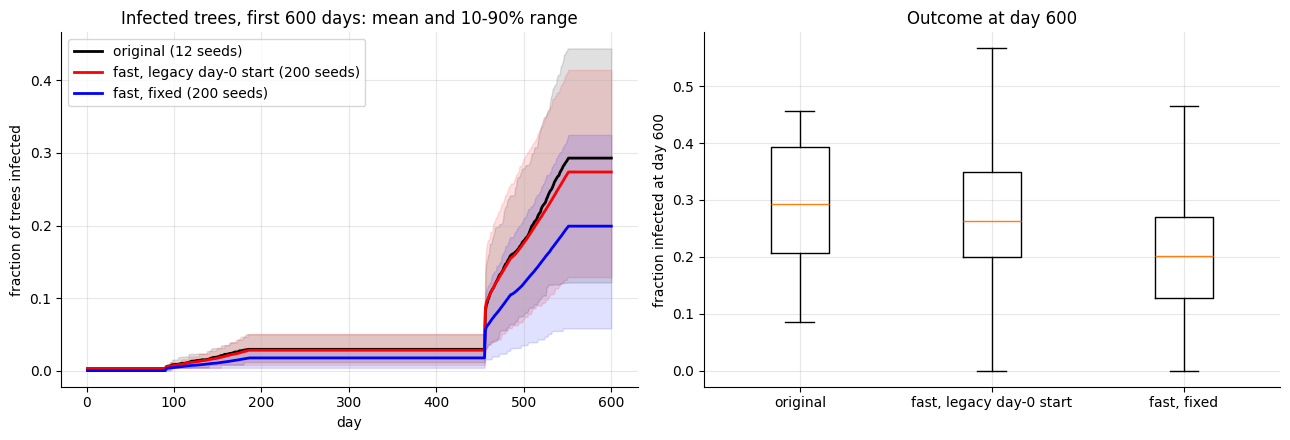

original                   day 600: mean 0.293  (standard error 0.037, 12 seeds)
fast, legacy day-0 start   day 600: mean 0.274  (standard error 0.008, 200 seeds)
fast, fixed                day 600: mean 0.199  (standard error 0.007, 200 seeds)

original vs fast legacy (should match):   Mann-Whitney p = 0.53
fast legacy vs fast fixed (the day-0 slip): Mann-Whitney p = 0.000
speed-up: 95x


In [4]:
with open('results/original_vs_fast.json') as f:
    comparison = json.load(f)

from scipy.stats import mannwhitneyu

versions = [('original', 'k', 'original'), ('fast_legacy', 'r', 'fast, legacy day-0 start'),
            ('fast_fixed', 'b', 'fast, fixed')]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, colour, label in versions:
    runs = np.array([r['infected'] for r in comparison[name]])
    days = np.arange(1, runs.shape[1] + 1)
    axes[0].fill_between(days, np.percentile(runs, 10, axis=0), np.percentile(runs, 90, axis=0),
                         color=colour, alpha=0.12)
    axes[0].plot(days, runs.mean(axis=0), color=colour, lw=2, label=f"{label} ({len(runs)} seeds)")
axes[0].set_xlabel('day')
axes[0].set_ylabel('fraction of trees infected')
axes[0].legend()
axes[0].set_title('Infected trees, first 600 days: mean and 10-90% range')

finals = {name: np.array([r['infected'][-1] for r in comparison[name]]) for name, _, _ in versions}
axes[1].boxplot([finals[n] for n, _, _ in versions])
axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels([l for _, _, l in versions])
axes[1].set_ylabel('fraction infected at day 600')
axes[1].set_title('Outcome at day 600')
plt.tight_layout()
plt.show()

for name, _, label in versions:
    f = finals[name]
    print(f"{label:26s} day 600: mean {f.mean():.3f}  (standard error {f.std(ddof=1)/np.sqrt(len(f)):.3f}, {len(f)} seeds)")
print(f"\noriginal vs fast legacy (should match):   Mann-Whitney p = "
      f"{mannwhitneyu(finals['original'], finals['fast_legacy']).pvalue:.2f}")
print(f"fast legacy vs fast fixed (the day-0 slip): Mann-Whitney p = "
      f"{mannwhitneyu(finals['fast_legacy'], finals['fast_fixed']).pvalue:.3f}")
timed = [r['secs'] for r in comparison['fast_fixed'] if r['secs'] is not None]   # the ones run one at a time
speed = np.mean([r['secs'] for r in comparison['original']]) / np.mean(timed)
print(f"speed-up: {speed:.0f}x")

The rewrite is faithful: with the original's day-0 behaviour switched back on, it matches
the original (0.27 against 0.29 of the grove infected by day 600; no detectable
difference, p = 0.53), and it runs about 95 times faster.

The fixed version is a different story. The day-0 slip - tender-sprout movement on the
first day of a hard-sprout season - raises infection at day 600 from 0.20 to 0.27, **a
38% increase** (p < 0.001). One wrong day at the start moves a two-year answer by more
than a third, because it lets the first carrier infect a tree a full season early.

Everything from here uses the fixed version.

## 3. One run is one roll of the dice

The same grove, the same single infected spittlebug at the start - but each run is a
different roll of the dice. Five years, so that symptoms, which take about two, have time
to appear.

40 runs of five years in 91 s


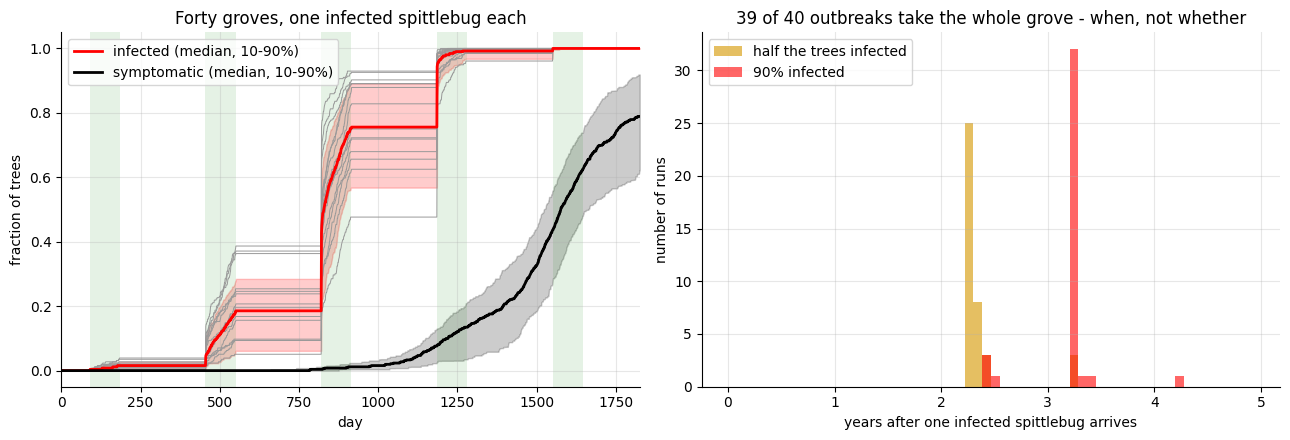

outbreaks that took off: 39 of 40; the rest infected [0.] of the grove
years to half the grove infected: median 2.27 (10-90% 2.25-2.42)
years to 90% infected:            median 3.25 (10-90% 3.10-3.27)
symptomatic after five years:     median 79%


In [5]:
t = time.time()
ensemble = run_ensemble(365 * 5, range(40), processes=PROCESSES, sampling_rate=0.001, time_steps_per_day=30)
print(f"40 runs of five years in {time.time() - t:.0f} s")

def fan(ax, runs, key, colour, label):
    values = np.array([r[key] for r in runs])
    days = runs[0]['day']
    ax.fill_between(days, np.percentile(values, 10, axis=0), np.percentile(values, 90, axis=0),
                    color=colour, alpha=0.2)
    ax.plot(days, np.median(values, axis=0), color=colour, lw=2, label=label)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for r in ensemble[:15]:
    axes[0].plot(r['day'], 1 - r['S'], color='0.6', lw=0.7)
fan(axes[0], [dict(day=r['day'], inf=1 - r['S']) for r in ensemble], 'inf', 'r', 'infected (median, 10-90%)')
fan(axes[0], ensemble, 'R', 'k', 'symptomatic (median, 10-90%)')
_shade_seasons(axes[0], 365 * 5)
axes[0].set_xlabel('day')
axes[0].set_ylabel('fraction of trees')
axes[0].set_title('Forty groves, one infected spittlebug each')
axes[0].legend(loc='upper left')

#every run ends with the whole grove infected, so the question is how fast
def day_reaching(run, level):
    infected = 1 - run['S']
    hit = np.where(infected >= level)[0]
    return run['day'][hit[0]] if len(hit) else np.nan

ever = np.array([r['ever_infected'] for r in ensemble])
half = np.array([day_reaching(r, 0.5) for r in ensemble])
most = np.array([day_reaching(r, 0.9) for r in ensemble])
bins = np.arange(0, 365 * 5 + 1, 30)
axes[1].hist(half / 365, bins=bins / 365, color='goldenrod', alpha=0.7, label='half the trees infected')
axes[1].hist(most / 365, bins=bins / 365, color='r', alpha=0.6, label='90% infected')
axes[1].set_xlabel('years after one infected spittlebug arrives')
axes[1].set_ylabel('number of runs')
took_off = ever > 0.5
axes[1].set_title(f'{took_off.sum()} of {len(ever)} outbreaks take the whole grove - when, not whether')
axes[1].legend()
plt.tight_layout()
plt.savefig('figures/fig2_ensemble.png', dpi=110, bbox_inches='tight')
plt.show()

print(f"outbreaks that took off: {took_off.sum()} of {len(ever)}; the rest infected {ever[~took_off]} of the grove")
print(f"years to half the grove infected: median {np.nanmedian(half)/365:.2f} "
      f"(10-90% {np.nanpercentile(half, 10)/365:.2f}-{np.nanpercentile(half, 90)/365:.2f})")
print(f"years to 90% infected:            median {np.nanmedian(most)/365:.2f} "
      f"(10-90% {np.nanpercentile(most, 10)/365:.2f}-{np.nanpercentile(most, 90)/365:.2f})")
print(f"symptomatic after five years:     median {np.median([r['R'][-1] for r in ensemble]):.0%}")

Thirty-nine of forty outbreaks take the whole grove within five years. The fortieth never
starts: the first carrier dies before it reaches a tree. Once an outbreak starts, its
*timing* is remarkably consistent - half the grove infected after about 2.3 years, 90%
after about 3.25, with a narrow spread.

The narrowness is set by the seasons, not by chance. Infection only moves during the
tender-sprout window, so outbreaks bunch up at the same point in the same season. And
symptoms lag about two years behind infection: after three years almost nothing looks
ill, while most of the grove is already infected. That gap is why felling the trees that
show symptoms comes too late, and it is the starting point for Part 2.

## 4. The assumptions doing the most work

### The annual reset

Every spring, on day 120, every spittlebug is replaced by an uninfected one. Biologically
reasonable - the bacterium does not survive the nymphs' moult, so each adult generation
starts clean - but it is a strong assumption. What happens without it?

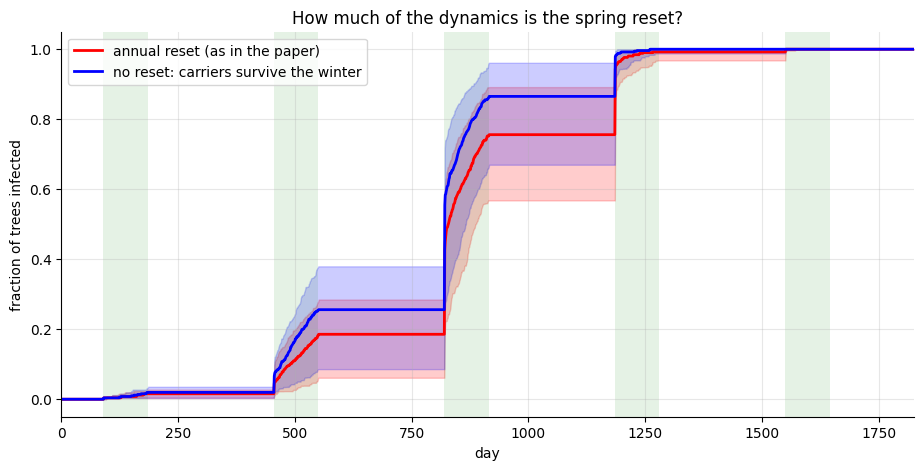

reset     years to half the grove: median 2.27   symptomatic after five years: median 79%
no reset  years to half the grove: median 2.25   symptomatic after five years: median 89%


In [6]:
no_reset = run_ensemble(365 * 5, range(40), processes=PROCESSES, sampling_rate=0.001,
                        time_steps_per_day=30, annual_reset=False)

fig, ax = plt.subplots()
fan(ax, [dict(day=r['day'], inf=1 - r['S']) for r in ensemble], 'inf', 'r', 'annual reset (as in the paper)')
fan(ax, [dict(day=r['day'], inf=1 - r['S']) for r in no_reset], 'inf', 'b', 'no reset: carriers survive the winter')
_shade_seasons(ax, 365 * 5)
ax.set_xlabel('day')
ax.set_ylabel('fraction of trees infected')
ax.set_title('How much of the dynamics is the spring reset?')
ax.legend(loc='upper left')
plt.show()

for label, runs in [('reset', ensemble), ('no reset', no_reset)]:
    h = np.array([day_reaching(r, 0.5) for r in runs]) / 365
    sym = np.median([r['R'][-1] for r in runs])
    print(f"{label:9s} years to half the grove: median {np.nanmedian(h):.2f}   "
          f"symptomatic after five years: median {sym:.0%}")

Almost no difference in pace: half the grove is infected at about the same time with or
without the reset. The annual steps come from the tender-sprout season, not from the
reset - outside that window spittlebugs sit in the shrub layer whether or not they still
carry the bacterium. What the reset does change is how many trees are already
symptomatic by year five: fewer with it than without, so it trims some of the earliest
infections. A strong-looking assumption that turns out to matter less than expected - and
that is worth knowing before spending effort on it.

### Infection on first contact

`tree_susceptibility = 1` means a carrier on a healthy tree infects it with certainty.
The original code's "sampling compensation", meant to adjust it, always returned 1.0, so
it was never actually varied.

One subtlety decides how to vary it: the probability applies **every time step** a
carrier spends on a tree - thirty times a day. So what matters is how long a visit lasts.
Measure it: follow every spittlebug through one tender-sprout season and count how many
consecutive steps it stays on the same tree.

In [7]:
probe = OliveGrove(sampling_rate=0.001, time_steps_per_day=30, seed=5)
probe.initialize_vectors(0)
probe.new_infections_today = 0
while probe.day < 90:                                # run up to the start of the tender season
    probe.step()

track = []
while probe.day < 186:                               # record every spittlebug's tree, every step
    probe.step()
    track.append(probe.tree_of_cell[probe.vector_y, probe.vector_x].copy())
track = np.array(track)                              # (steps, spittlebugs)

visit_lengths = []
for v in range(track.shape[1]):
    trees = track[:, v]
    change = np.flatnonzero(np.diff(trees) != 0) + 1
    for segment in np.split(trees, change):
        if segment[0] >= 0:                          # a stay on a tree, not on shrub
            visit_lengths.append(len(segment))
visit_lengths = np.array(visit_lengths)
print(f"{len(visit_lengths)} visits; median {np.median(visit_lengths):.0f} steps "
      f"({np.median(visit_lengths)/30:.1f} days), mean {visit_lengths.mean():.0f} steps")

def per_visit(p):
    #probability a carrier infects the tree at least once during a visit, averaged over visits
    return np.mean(1 - (1 - p) ** visit_lengths)

for p in [1.0, 0.1, 0.01, 0.001, 0.0001]:
    print(f"per-step {p:7.4f}  ->  per-visit {per_visit(p):.2f}")

3401 visits; median 527 steps (17.6 days), mean 633 steps
per-step  1.0000  ->  per-visit 1.00
per-step  0.1000  ->  per-visit 0.99
per-step  0.0100  ->  per-visit 0.89
per-step  0.0010  ->  per-visit 0.41
per-step  0.0001  ->  per-visit 0.06


A visit lasts a median of about 530 steps - nearly eighteen days. With thirty chances a
day, a per-step probability of 0.1 is certainty per visit, and even 0.001 per step is a
41% chance. So the original's value of 1 was not merely strong; it is far beyond the range
where the value matters at all. The meaningful scale is per visit, and the sweep below
uses it.

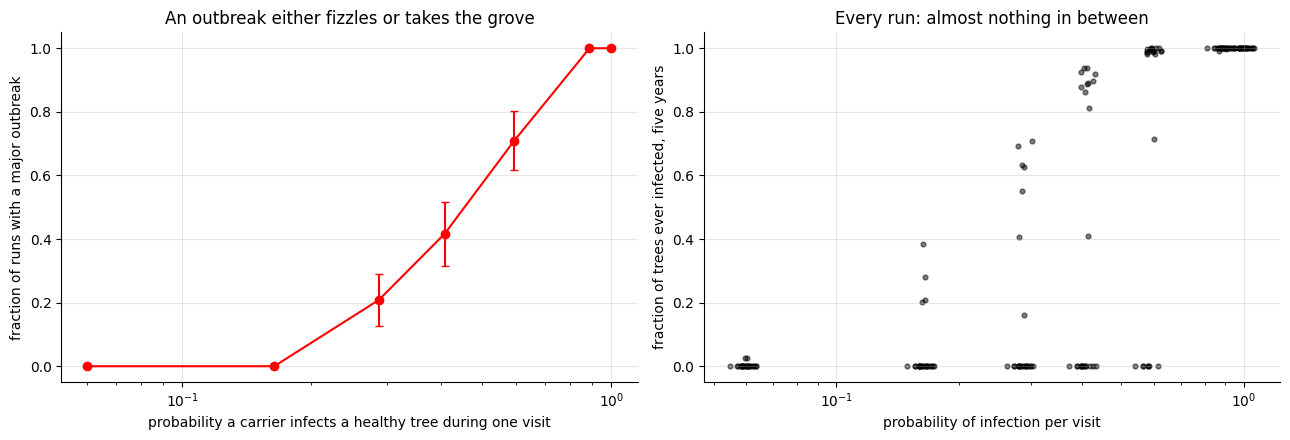

per step  1.0000  per visit  100%:  major outbreak in 100% of runs
per step  0.0100  per visit   89%:  major outbreak in 100% of runs
per step  0.0020  per visit   59%:  major outbreak in  71% of runs
per step  0.0010  per visit   41%:  major outbreak in  42% of runs
per step  0.0006  per visit   29%:  major outbreak in  21% of runs
per step  0.0003  per visit   16%:  major outbreak in   0% of runs
per step  0.0001  per visit    6%:  major outbreak in   0% of runs


In [8]:
susceptibility_levels = [1.0, 0.01, 0.002, 0.001, 0.0006, 0.0003, 0.0001]
by_susceptibility = {}
for level in susceptibility_levels:
    runs = run_ensemble(365 * 5, range(24), processes=PROCESSES, sampling_rate=0.001,
                        time_steps_per_day=30, tree_susceptibility=level)
    by_susceptibility[level] = np.array([r['ever_infected'] for r in runs])

#an outbreak either fizzles or takes the grove, so count how often it takes off
visit_p = np.array([per_visit(l) for l in susceptibility_levels])
major = np.array([np.mean(by_susceptibility[l] > 0.5) for l in susceptibility_levels])
n_runs = len(by_susceptibility[susceptibility_levels[0]])
err = np.sqrt(major * (1 - major) / n_runs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].errorbar(visit_p, major, yerr=err, fmt='o-', color='r', capsize=3)
axes[0].set_xscale('log')
axes[0].set_xlabel('probability a carrier infects a healthy tree during one visit')
axes[0].set_ylabel('fraction of runs with a major outbreak')
axes[0].set_title('An outbreak either fizzles or takes the grove')

for l, vp in zip(susceptibility_levels, visit_p):
    axes[1].scatter(np.full(n_runs, vp) * np.exp(np.random.default_rng(0).normal(0, 0.04, n_runs)),
                    by_susceptibility[l], s=12, color='k', alpha=0.5)
axes[1].set_xscale('log')
axes[1].set_xlabel('probability of infection per visit')
axes[1].set_ylabel('fraction of trees ever infected, five years')
axes[1].set_title('Every run: almost nothing in between')
plt.tight_layout()
plt.savefig('figures/fig3_threshold.png', dpi=110, bbox_inches='tight')
plt.show()

for level, vp, m in zip(susceptibility_levels, visit_p, major):
    print(f"per step {level:7.4f}  per visit {vp:5.0%}:  major outbreak in {m:4.0%} of runs")

The grove sits on a threshold. Below about 16% per visit, no outbreak out of 24 takes off.
Above about 90%, every one does. In between it is a coin toss whether an outbreak fizzles
or takes everything - and almost no run ends anywhere in between (right panel).

That all-or-nothing behaviour is the signature of a **percolation threshold**, and it is
the subject of Part 2: predict where the threshold sits from one measured run, without
sweeping, and turn it into the felling radius that keeps a grove on the safe side. The
setting the paper used, infection on first contact, is far above it - which is why every
outbreak in section 3 took the whole grove.

### The biggest approximation: 0.1% of the spittlebugs

The paper simulates a million spittlebugs per hectare - 810,000 in this grove. The
original code runs 810, because anything more was too slow. The fast version makes it
possible to ask what that costs.

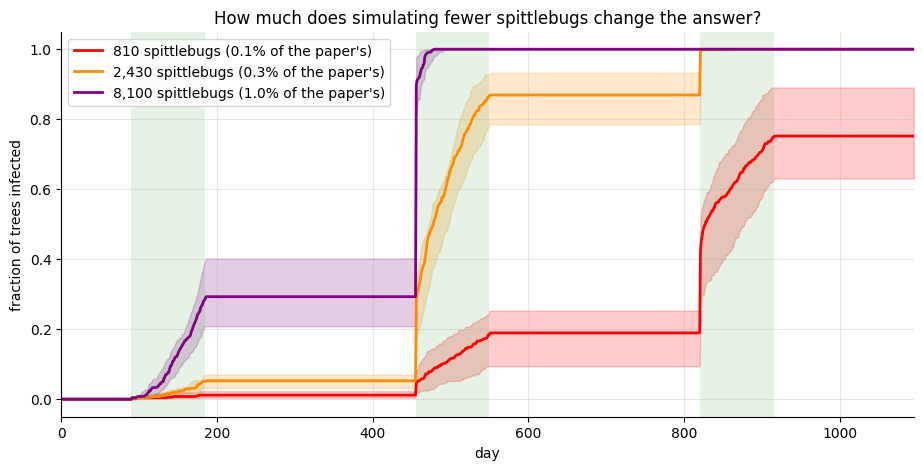

   810 spittlebugs: after 3 years, median 75% infected, 3% symptomatic   (18 s for 12 runs)
 2,430 spittlebugs: after 3 years, median 100% infected, 17% symptomatic   (32 s for 12 runs)
 8,100 spittlebugs: after 3 years, median 100% infected, 42% symptomatic   (79 s for 12 runs)


In [9]:
rates = [0.001, 0.003, 0.01]
by_rate, seconds = {}, {}
for rate in rates:
    t = time.time()
    runs = run_ensemble(365 * 3, range(12), processes=PROCESSES, sampling_rate=rate, time_steps_per_day=30)
    seconds[rate] = time.time() - t
    by_rate[rate] = runs

fig, ax = plt.subplots()
for rate, colour in zip(rates, ['r', 'darkorange', 'purple']):
    n_vectors = int(810_000 * rate)
    fan(ax, [dict(day=r['day'], inf=1 - r['S']) for r in by_rate[rate]], 'inf', colour,
        f"{n_vectors:,} spittlebugs ({rate:.1%} of the paper's)")
_shade_seasons(ax, 365 * 3)
ax.set_xlabel('day')
ax.set_ylabel('fraction of trees infected')
ax.set_title('How much does simulating fewer spittlebugs change the answer?')
ax.legend(loc='upper left')
plt.show()

for rate in rates:
    e = np.array([r['ever_infected'] for r in by_rate[rate]])
    sym = np.median([r['R'][-1] for r in by_rate[rate]])
    print(f"{int(810_000*rate):6,d} spittlebugs: after 3 years, median {np.median(e):.0%} infected, "
          f"{sym:.0%} symptomatic   ({seconds[rate]:.0f} s for 12 runs)")

More spittlebugs, faster epidemic. With 810 the grove is about three-quarters infected
after three years; with 2,430 or 8,100 it is completely infected, and far more of it is
already symptomatic. More spittlebugs means more visits, and every visit is a chance to
pass the bacterium on.

So the 0.1% sampling is not a neutral shortcut: it makes the epidemic look slower than
the model says it is, and the results above are on the conservative side. The fast
version can now run 1% routinely; the paper's full density, 810,000 spittlebugs, is still
out of reach on a laptop. Part 2 measures transmission at the higher density.

## What this notebook establishes

- **The rewrite is the same model** - it matches the original's outcomes (p = 0.53) and
  runs about 95 times faster, which is what makes everything after section 2 possible.
- **A one-day slip moved a two-year answer by more than a third.** The original's day-0
  tender-sprout start let the first carrier infect a tree a season early.
- **Outbreaks are all-or-nothing.** Almost every run either fizzles at once or takes the
  whole grove; what varies is the timing, set by the seasons.
- **The spring reset matters less than it looks; spittlebug density matters more.**
- **There is a sharp threshold** in how readily a carrier infects a tree during a visit -
  below it outbreaks die out, above it they take the grove. Finding that threshold from a
  single measured run, and turning it into a felling rule, is Part 2.